# Customer Segmentation

### Reading Data

In [228]:
import pandas as pd
import numpy as np
from sklearn.preprocessing import StandardScaler
from sklearn.cluster import KMeans
import matplotlib.pyplot as plt
import sklearn.metrics as silhouette_score
import seaborn as sns

customer_metrics = pd.read_csv('../data/processed/customer_metrics_without_outliers.csv')

In [229]:
customer_metrics.head()

,CustomerID,TotalSpent,OrderCount,FirstInvoiceDate,LastInvoiceDate,CustomerLifespan,Recency,PurchaseFrequency
0,12348.0,1437.24,4,2010-12-16 19:09:00,2011-09-25 13:13:00,282,74,0.43
1,12349.0,1457.55,1,2011-11-21 09:51:00,2011-11-21 09:51:00,1,18,30.00
2,12350.0,294.40,1,2011-02-02 16:01:00,2011-02-02 16:01:00,1,309,30.00
3,12352.0,1385.74,7,2011-02-16 12:33:00,2011-11-03 14:37:00,260,35,0.81
4,12353.0,89.00,1,2011-05-19 17:47:00,2011-05-19 17:47:00,1,203,30.00


### Scaling Features

In [230]:
segmentation_features = ['TotalSpent', 'PurchaseFrequency', 'Recency']

scaler = StandardScaler()
scaled_features = scaler.fit_transform(customer_metrics[segmentation_features]) # numpy array with standard deviation

scaled_features_df = pd.DataFrame(scaled_features, index=customer_metrics.index, \
                                  columns=('TotalSpent', 'PurchaseFrequency', 'Recency'))


In [231]:
scaled_features

array([[ 0.68919658, -0.83281884, -0.24605843],
       [ 0.7141061 ,  1.11799514, -0.79647924],
       [-0.71245714,  1.11799514,  2.06374321],
       ...,
       [-0.85515639, -0.82754102, -0.90459762],
       [ 1.48847182, -0.76618637, -0.94391339],
       [ 1.1798318 , -0.82358265, -0.56058461]])

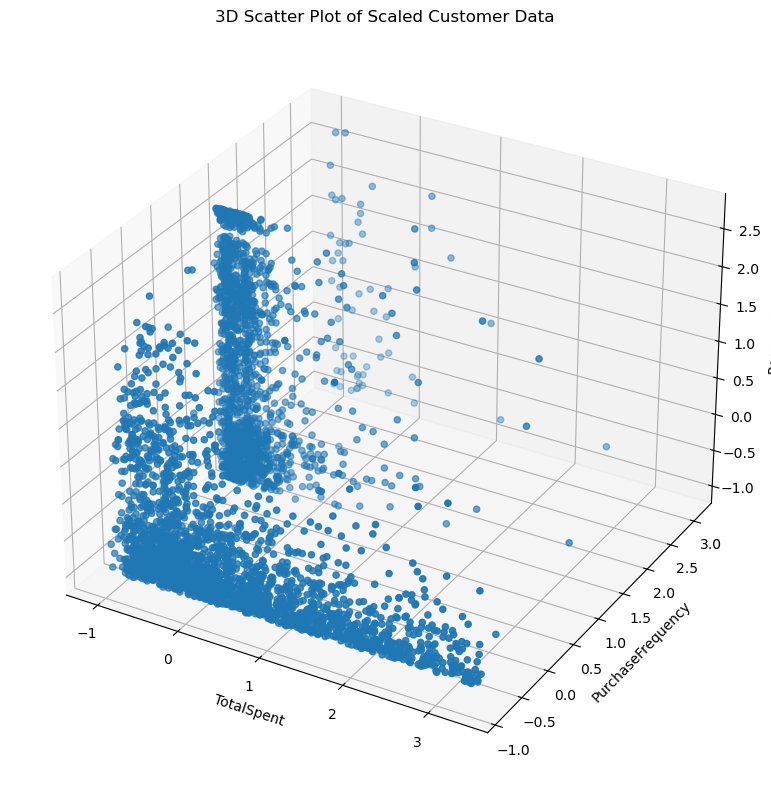

In [232]:
fig = plt.figure(figsize=(8, 8))

ax = fig.add_subplot(projection='3d')
ax.scatter(
  scaled_features_df['TotalSpent'],
  scaled_features_df['PurchaseFrequency'],
  scaled_features_df['Recency']
)
ax.set_xlabel('TotalSpent')
ax.set_ylabel('PurchaseFrequency')
ax.set_zlabel('Recency')
ax.set_title('3D Scatter Plot of Scaled Customer Data')

plt.tight_layout()
plt.show()

### Finding out Optimal Clusters

In [233]:
inertias = []
silhouette_scores = [] #-1 - 1 score to determine cluster overlapping (high means less overlap)
k_values = range(2, 11)

for k in k_values:
  kmeans = KMeans(n_clusters=k, random_state=42, max_iter=1000, n_init='auto')
  cluster_labels = kmeans.fit_predict(scaled_features_df)
  sil_score = silhouette_score.silhouette_score(scaled_features_df, cluster_labels)
  silhouette_scores.append(sil_score)
  inertias.append(kmeans.inertia_)

scaled_features_df

,TotalSpent,PurchaseFrequency,Recency
0,0.689197,-0.832819,-0.246058
1,0.714106,1.117995,-0.796479
2,-0.712457,1.117995,2.063743
3,0.626034,-0.807749,-0.629387
4,-0.964373,1.117995,1.021875
...,...,...,...
3899,-0.852029,1.117995,1.749217
3900,-0.974406,1.117995,0.795810
3901,-0.855156,-0.827541,-0.904598
3902,1.488472,-0.766186,-0.943913


### Plotting Elbow Curve

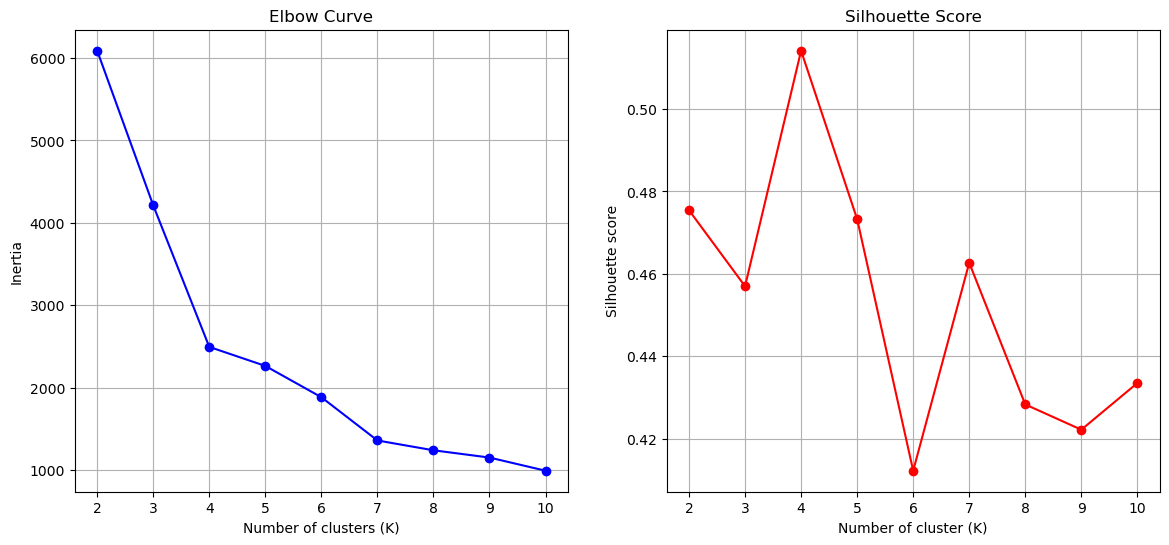

In [234]:
plt.figure(figsize=(14, 6))

plt.subplot(1, 2, 1)
plt.plot(k_values, inertias, 'bo-')
plt.xlabel('Number of clusters (K)')
plt.ylabel('Inertia')
plt.grid(True)
plt.title('Elbow Curve')

plt.subplot(1, 2, 2)
plt.plot(k_values, silhouette_scores, 'ro-')
plt.xlabel('Number of cluster (K)')
plt.ylabel('Silhouette score')
plt.grid(True)

plt.title('Silhouette Score')
plt.show()

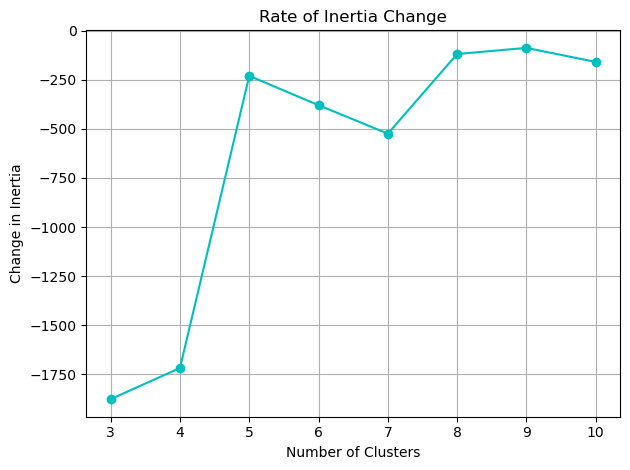

In [235]:
inertia_changes = np.diff(inertias)
plt.plot(k_values[1:], inertia_changes, 'co-')
plt.xlabel('Number of Clusters')
plt.ylabel('Change in Inertia')
plt.title('Rate of Inertia Change')
plt.tight_layout()
plt.grid(True)
plt.show()

### Segmenting Customers

In [236]:
kmeans_5 = KMeans(n_clusters=5, random_state=42)
customer_metrics_test = customer_metrics.copy()
customer_metrics_test['Segment'] = kmeans_5.fit_predict(scaled_features)

kmeans_4 = KMeans(n_clusters=4, random_state=42)
customer_metrics['Segment'] = kmeans_4.fit_predict(scaled_features)

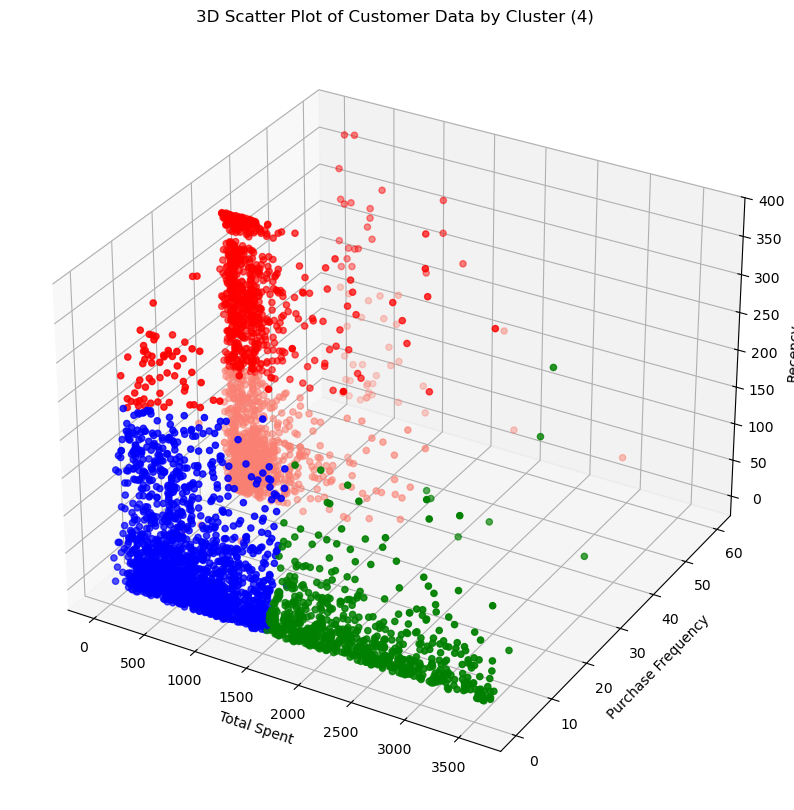

In [237]:
cluster_colors = {
  0: 'blue',
  1: 'salmon',
  2: 'green',
  3: 'red'
}

colors = customer_metrics['Segment'].map(cluster_colors)

fig = plt.figure(figsize=(10, 10))
ax = fig.add_subplot(projection='3d')

scatter = ax.scatter(customer_metrics['TotalSpent'],
                     customer_metrics['PurchaseFrequency'],
                     customer_metrics['Recency'],
                     c=colors,
                     marker='o')

ax.set_xlabel('Total Spent')
ax.set_ylabel('Purchase Frequency')
ax.set_zlabel('Recency')
ax.set_title('3D Scatter Plot of Customer Data by Cluster (4)')
plt.show()

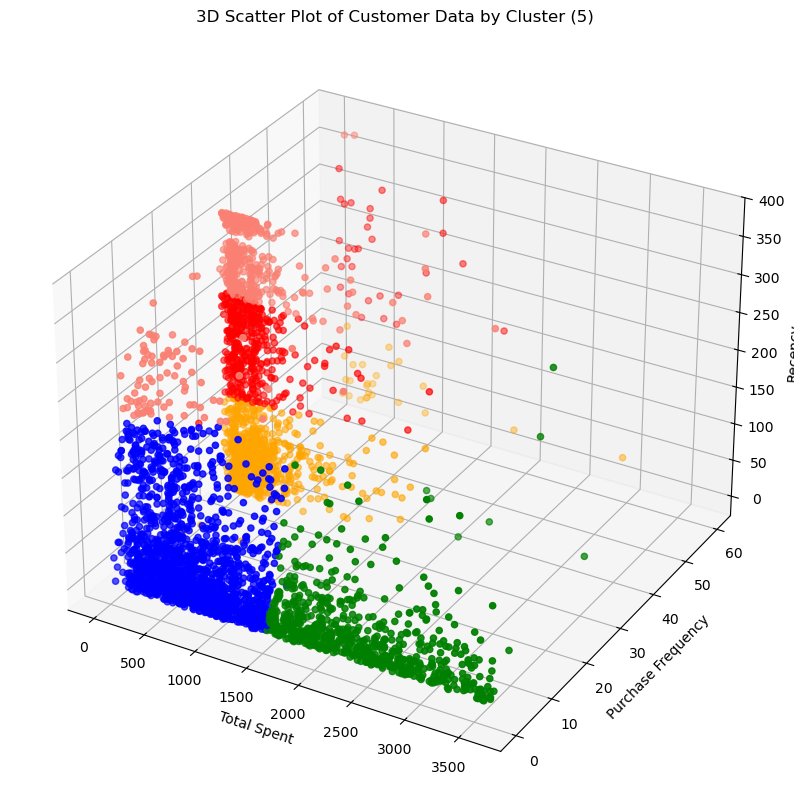

In [238]:
cluster_colors_1 = {
  0: 'blue',
  1: 'orange',
  2: 'green',
  3: 'red',
  4: 'salmon'
}

colors = customer_metrics_test['Segment'].map(cluster_colors_1)

fig = plt.figure(figsize=(10, 10))
ax = fig.add_subplot(projection='3d')

scatter = ax.scatter(customer_metrics_test['TotalSpent'],
                     customer_metrics_test['PurchaseFrequency'],
                     customer_metrics_test['Recency'],
                     c=colors,
                     marker='o')

ax.set_xlabel('Total Spent')
ax.set_ylabel('Purchase Frequency')
ax.set_zlabel('Recency')
ax.set_title('3D Scatter Plot of Customer Data by Cluster (5)')
plt.show()

### Visualizing Segment Spread in RFM 

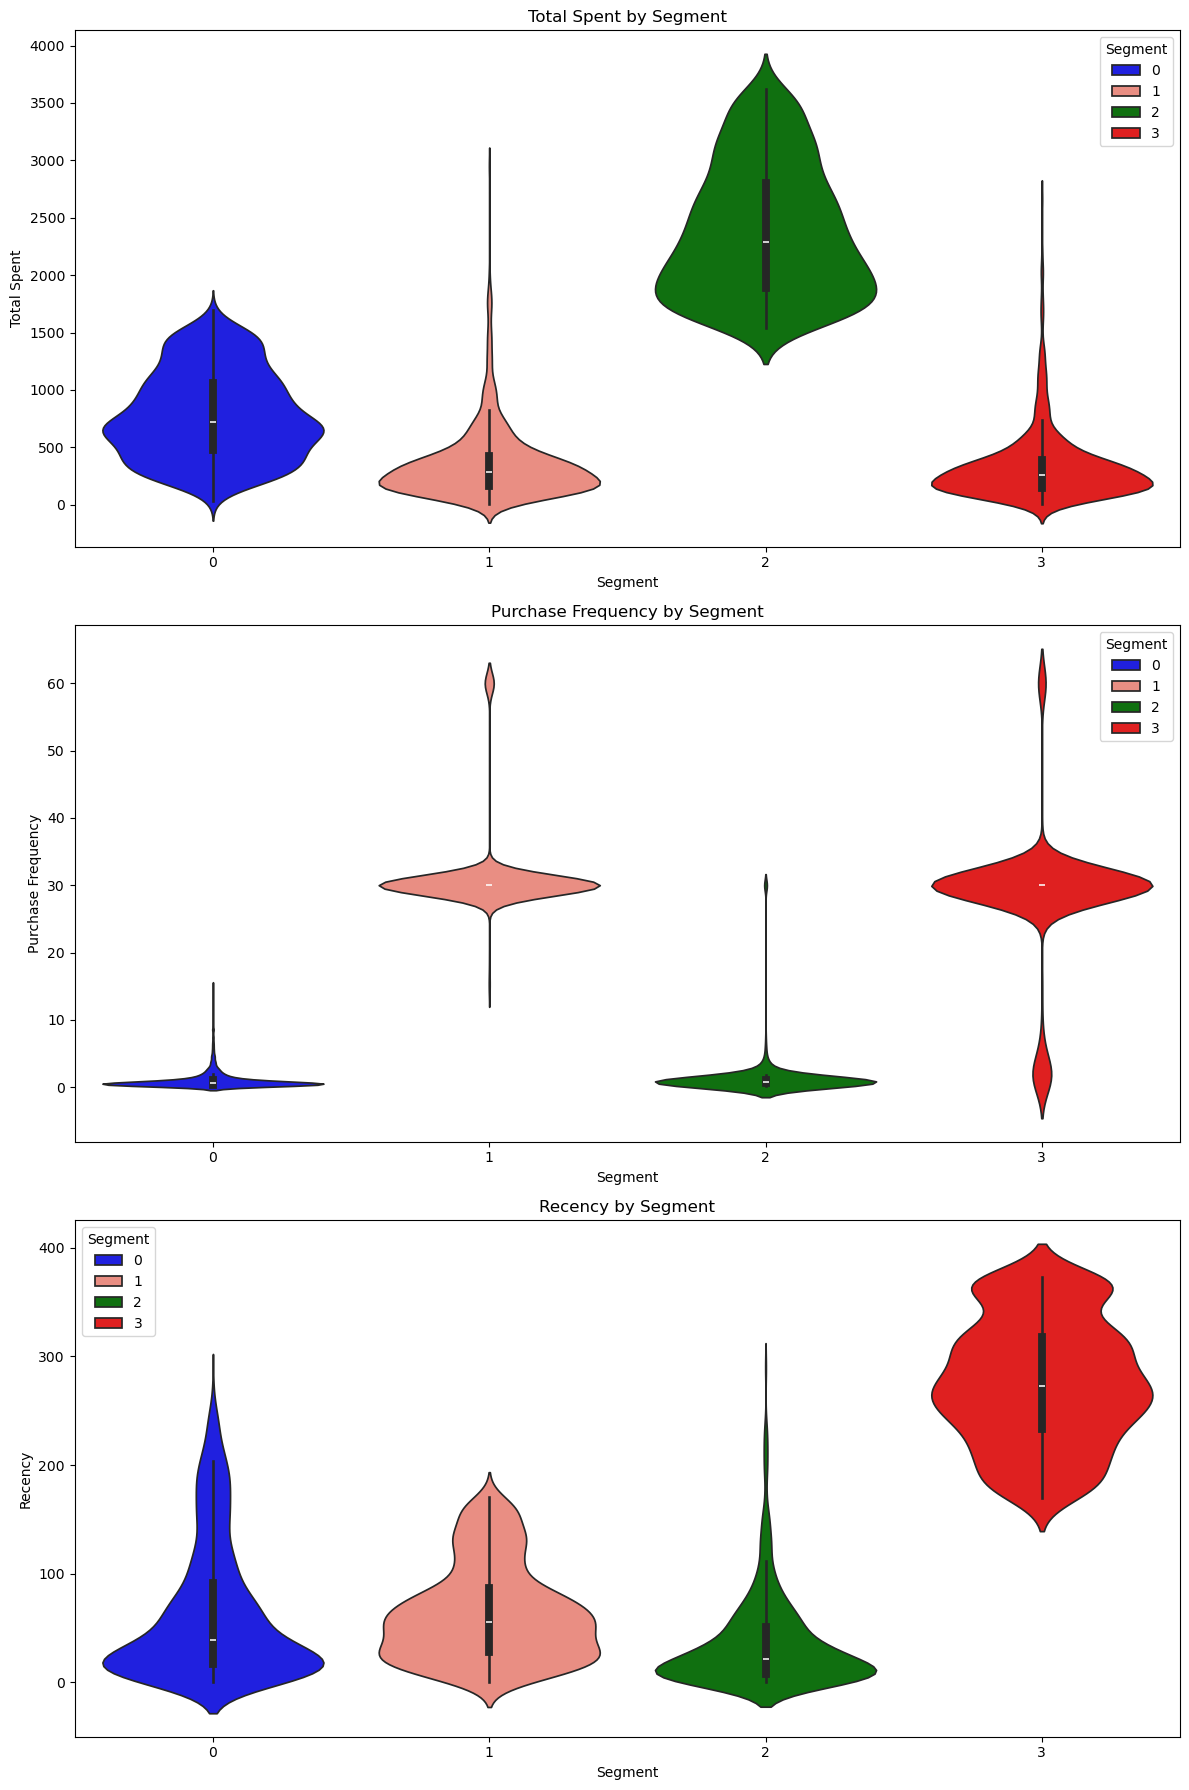

In [239]:
plt.figure(figsize=(12, 18))

plt.subplot(3, 1, 1)
sns.violinplot(x='Segment', y='TotalSpent', data=customer_metrics, palette=cluster_colors, hue='Segment')
plt.title('Total Spent by Segment')
plt.ylabel('Total Spent')

plt.subplot(3, 1, 2)
sns.violinplot(x='Segment', y='PurchaseFrequency', data=customer_metrics, palette=cluster_colors, hue='Segment')
plt.title('Purchase Frequency by Segment')
plt.ylabel('Purchase Frequency')

plt.subplot(3, 1, 3)
sns.violinplot(x='Segment', y='Recency', data=customer_metrics, palette=cluster_colors, hue='Segment')
plt.title('Recency by Segment')
plt.ylabel('Recency')

plt.tight_layout()
plt.show()

In [240]:
segment_analysis = customer_metrics.groupby('Segment').agg(
  AvgTotalSpent= ('TotalSpent','mean'),
  TotalSpentCount= ('TotalSpent', 'count'),
  AvgPurchaseFrequency= ('PurchaseFrequency', 'mean'),
  AvgCustomerLifespan= ('CustomerLifespan', 'mean')
).round(2)
segment_analysis

,AvgTotalSpent,TotalSpentCount,AvgPurchaseFrequency,AvgCustomerLifespan
Segment,,,,
0,779.16,1608,1.02,169.64
1,359.22,878,31.10,1.02
2,2377.40,673,1.26,241.04
3,334.10,745,28.42,5.18


### Adding Segment Labels

In [241]:
def label_segments(row):
  if row['AvgTotalSpent'] > 1800 and row['AvgPurchaseFrequency'] < 3:
    return('HighValueIrregular')
  elif row['AvgTotalSpent'] > 500 and row['AvgPurchaseFrequency'] < 3:
    return('HighSpendingIrregular')
  elif row['AvgPurchaseFrequency'] > 30 and row['AvgCustomerLifespan'] < 3:
    return('BudgetOld')
  elif row['AvgPurchaseFrequency'] < 30 and row['AvgCustomerLifespan'] > 3:
    return('BudgetNew')
  else:
    return('Oulier')

segment_analysis['SegmentLabel'] = segment_analysis.apply(label_segments, axis=1)
segment_analysis

,AvgTotalSpent,TotalSpentCount,AvgPurchaseFrequency,AvgCustomerLifespan,SegmentLabel
Segment,,,,,
0,779.16,1608,1.02,169.64,HighSpendingIrregular
1,359.22,878,31.10,1.02,BudgetOld
2,2377.40,673,1.26,241.04,HighValueIrregular
3,334.10,745,28.42,5.18,BudgetNew


In [242]:
segment_analysis.columns = ['AvgTotalSpent', 'TotalSpentCount', 'AvgPurchaseFrequency', 'AvgCustomerLifespan', 'SegmentLabel']

### Visualizing Segments

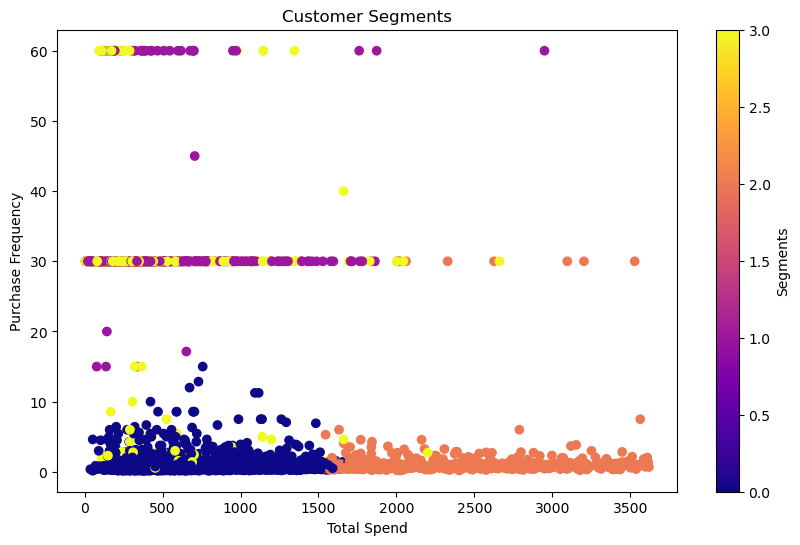

In [243]:
plt.figure(figsize=(10, 6))
scatter = plt.scatter(customer_metrics['TotalSpent'],
                      customer_metrics['PurchaseFrequency'],
                      c=customer_metrics['Segment'],
                      cmap='plasma'
                      )
plt.xlabel('Total Spend')
plt.ylabel('Purchase Frequency')
plt.title('Customer Segments')
plt.colorbar(label='Segments')

plt.show()

In [244]:
customer_metrics.head()

,CustomerID,TotalSpent,OrderCount,FirstInvoiceDate,LastInvoiceDate,CustomerLifespan,Recency,PurchaseFrequency,Segment
0,12348.0,1437.24,4,2010-12-16 19:09:00,2011-09-25 13:13:00,282,74,0.43,0
1,12349.0,1457.55,1,2011-11-21 09:51:00,2011-11-21 09:51:00,1,18,30.00,1
2,12350.0,294.40,1,2011-02-02 16:01:00,2011-02-02 16:01:00,1,309,30.00,3
3,12352.0,1385.74,7,2011-02-16 12:33:00,2011-11-03 14:37:00,260,35,0.81,0
4,12353.0,89.00,1,2011-05-19 17:47:00,2011-05-19 17:47:00,1,203,30.00,3


In [245]:
segment_label = {
  0: 'BudgetRegular',
  1: 'BudgetIrregular',
  2: 'HighValueIrregular',
  3: 'HighSpendingIrregular'
}
customer_metrics.reset_index()
customer_metrics['SegmentLabel'] = customer_metrics['Segment'].map(segment_label)

### Exporting Data

In [246]:
segment_analysis.to_csv('../data/processed/customer_segments.csv', index=False)
customer_metrics.to_csv('../data/processed/customer_metrics_segments.csv', index=False)